In [64]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [65]:
# Cargar el dataset EMNIST
def cargar_emnist(subset='balanced', metodo='tfds'):
    """
    Carga el dataset EMNIST usando TensorFlow Datasets (más confiable)
    
    Parámetros:
    - subset: 'balanced', 'byclass', 'bymerge', 'letters', 'digits', 'mnist'
    - metodo: 'tfds' (TensorFlow Datasets) o 'extra_keras' (extra_keras_datasets)
    """
    
    if metodo == 'tfds':
        try:
            import tensorflow_datasets as tfds
            
            # Mapeo de nombres
            dataset_name = f'emnist/{subset}'
            
            print(f"Descargando EMNIST ({subset}) con TensorFlow Datasets...")
            
            # Cargar dataset
            ds_train = tfds.load(dataset_name, split='train', as_supervised=True, shuffle_files=False)
            ds_test = tfds.load(dataset_name, split='test', as_supervised=True, shuffle_files=False)
            
            # Convertir a numpy arrays
            x_train, y_train = [], []
            for image, label in tfds.as_numpy(ds_train):
                x_train.append(image)
                y_train.append(label)
            
            x_test, y_test = [], []
            for image, label in tfds.as_numpy(ds_test):
                x_test.append(image)
                y_test.append(label)
            
            x_train = np.array(x_train).squeeze()
            y_train = np.array(y_train)
            x_test = np.array(x_test).squeeze()
            y_test = np.array(y_test)
            
            print(f"✓ Datos cargados exitosamente")
            
            return (x_train, y_train), (x_test, y_test)
            
        except ImportError:
            print("⚠ TensorFlow Datasets no está instalado.")
            print("Instálalo con: pip install tensorflow-datasets")
            raise
        except Exception as e:
            print(f"Error al cargar con TensorFlow Datasets: {e}")
            print("Intentando con método alternativo...")
            metodo = 'extra_keras'
    
    if metodo == 'extra_keras':
        try:
            from extra_keras_datasets import emnist
            import os
            
            # Eliminar archivo corrupto si existe
            cache_dir = os.path.expanduser('~/.keras/datasets')
            zip_path = os.path.join(cache_dir, 'matlab.zip')
            
            if os.path.exists(zip_path):
                print(f"Eliminando archivo corrupto: {zip_path}")
                os.remove(zip_path)
            
            print(f"Descargando EMNIST ({subset}) con extra_keras_datasets...")
            (x_train, y_train), (x_test, y_test) = emnist.load_data(type=subset)
            
            print(f"✓ Datos cargados exitosamente")
            
            return (x_train, y_train), (x_test, y_test)
            
        except ImportError:
            print("⚠ extra_keras_datasets no está instalado.")
            print("Instálalo con: pip install extra-keras-datasets")
            raise
        except Exception as e:
            print(f"Error al cargar con extra_keras_datasets: {e}")
            raise

In [66]:
# EXPLORACIÓN DE DATOS
def explorar_dimensiones(x_train, y_train, x_test, y_test):
    """
    Muestra información básica sobre las dimensiones del dataset
    """
    print("\n" + "="*60)
    print("INFORMACIÓN BÁSICA DEL DATASET")
    print("="*60)
    
    print(f"\nConjunto de entrenamiento:")
    print(f"  - Imágenes: {x_train.shape}")
    print(f"  - Etiquetas: {y_train.shape}")
    print(f"  - Tipo de datos (X): {x_train.dtype}")
    print(f"  - Tipo de datos (y): {y_train.dtype}")
    
    print(f"\nConjunto de prueba:")
    print(f"  - Imágenes: {x_test.shape}")
    print(f"  - Etiquetas: {y_test.shape}")
    
    print(f"\nCaracterísticas de las imágenes:")
    print(f"  - Tamaño: {x_train.shape[1]}x{x_train.shape[2]} píxeles")
    print(f"  - Rango de valores: [{x_train.min()}, {x_train.max()}]")
    print(f"  - Valor medio: {x_train.mean():.2f}")
    print(f"  - Desviación estándar: {x_train.std():.2f}")

def explorar_clases(y_train, y_test):
    """
    Analiza la distribución de clases en el dataset
    """
    print("\n" + "="*60)
    print("ANÁLISIS DE CLASES")
    print("="*60)
    
    clases_unicas_train = np.unique(y_train)
    clases_unicas_test = np.unique(y_test)
    
    print(f"\nNúmero de clases en entrenamiento: {len(clases_unicas_train)}")
    print(f"Número de clases en prueba: {len(clases_unicas_test)}")
    print(f"Rango de clases: {clases_unicas_train.min()} - {clases_unicas_train.max()}")
    
    # Contar muestras por clase
    counter_train = Counter(y_train)
    counter_test = Counter(y_test)
    
    print(f"\nEstadísticas de muestras por clase (Train):")
    muestras_train = list(counter_train.values())
    print(f"  - Mínimo: {min(muestras_train)} muestras")
    print(f"  - Máximo: {max(muestras_train)} muestras")
    print(f"  - Media: {np.mean(muestras_train):.0f} muestras")
    print(f"  - Mediana: {np.median(muestras_train):.0f} muestras")
    
    return counter_train, counter_test

In [67]:
def visualizar_distribucion_clases(counter_train, counter_test):
    """
    Visualiza la distribución de clases en ambos conjuntos
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Training set
    clases_train = sorted(counter_train.keys())
    conteos_train = [counter_train[c] for c in clases_train]
    
    axes[0].bar(clases_train, conteos_train, color='steelblue', alpha=0.7)
    axes[0].set_xlabel('Clase', fontsize=12)
    axes[0].set_ylabel('Número de muestras', fontsize=12)
    axes[0].set_title('Distribución de Clases - Entrenamiento', fontsize=14, fontweight='bold')
    axes[0].grid(axis='y', alpha=0.3)
    
    # Test set
    clases_test = sorted(counter_test.keys())
    conteos_test = [counter_test[c] for c in clases_test]
    
    axes[1].bar(clases_test, conteos_test, color='coral', alpha=0.7)
    axes[1].set_xlabel('Clase', fontsize=12)
    axes[1].set_ylabel('Número de muestras', fontsize=12)
    axes[1].set_title('Distribución de Clases - Prueba', fontsize=14, fontweight='bold')
    axes[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def visualizar_muestras_aleatorias(x_train, y_train, n_muestras=20):
    """
    Muestra ejemplos aleatorios del dataset
    """
    indices = np.random.choice(len(x_train), n_muestras, replace=False)
    
    filas = 4
    cols = 5
    fig, axes = plt.subplots(filas, cols, figsize=(15, 12))
    fig.suptitle('Muestras Aleatorias del Dataset', fontsize=16, fontweight='bold')
    
    for i, idx in enumerate(indices):
        fila = i // cols
        col = i % cols
        
        axes[fila, col].imshow(x_train[idx], cmap='gray')
        axes[fila, col].set_title(f'Clase: {y_train[idx]}', fontsize=10)
        axes[fila, col].axis('off')
    
    plt.tight_layout()
    plt.show()

def visualizar_muestras_por_clase(x_train, y_train, n_clases=10, n_ejemplos=10):
    """
    Muestra múltiples ejemplos de varias clases
    """
    clases_unicas = np.unique(y_train)
    clases_seleccionadas = np.random.choice(clases_unicas, min(n_clases, len(clases_unicas)), replace=False)
    
    fig, axes = plt.subplots(n_clases, n_ejemplos, figsize=(20, 2*n_clases))
    fig.suptitle('Ejemplos por Clase', fontsize=16, fontweight='bold')
    
    for i, clase in enumerate(clases_seleccionadas):
        # Obtener índices de esta clase
        indices_clase = np.where(y_train == clase)[0]
        indices_muestra = np.random.choice(indices_clase, min(n_ejemplos, len(indices_clase)), replace=False)
        
        for j, idx in enumerate(indices_muestra):
            if n_clases == 1:
                ax = axes[j]
            else:
                ax = axes[i, j]
            
            ax.imshow(x_train[idx], cmap='gray')
            if j == 0:
                ax.set_ylabel(f'Clase {clase}', fontsize=10, fontweight='bold')
            ax.axis('off')
    
    plt.tight_layout()
    plt.show()

In [68]:
def analizar_intensidad_pixeles(x_train):
    """
    Analiza la distribución de intensidad de píxeles
    """
    print("\n" + "="*60)
    print("ANÁLISIS DE INTENSIDAD DE PÍXELES")
    print("="*60)
    
    # Calcular estadísticas
    pixel_media = x_train.mean(axis=0)
    pixel_std = x_train.std(axis=0)
    
    print(f"\nIntensidad promedio global: {x_train.mean():.2f}")
    print(f"Desviación estándar global: {x_train.std():.2f}")
    
    # Visualizar
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Histograma de intensidades
    axes[0].hist(x_train.flatten(), bins=50, color='navy', alpha=0.7, edgecolor='black')
    axes[0].set_xlabel('Valor de píxel', fontsize=12)
    axes[0].set_ylabel('Frecuencia', fontsize=12)
    axes[0].set_title('Distribución de Intensidad de Píxeles', fontsize=14, fontweight='bold')
    axes[0].grid(alpha=0.3)
    
    # Mapa de calor de media
    im1 = axes[1].imshow(pixel_media, cmap='hot')
    axes[1].set_title('Intensidad Media por Píxel', fontsize=14, fontweight='bold')
    axes[1].axis('off')
    plt.colorbar(im1, ax=axes[1])
    
    # Mapa de calor de desviación estándar
    im2 = axes[2].imshow(pixel_std, cmap='viridis')
    axes[2].set_title('Desviación Estándar por Píxel', fontsize=14, fontweight='bold')
    axes[2].axis('off')
    plt.colorbar(im2, ax=axes[2])
    
    plt.tight_layout()
    plt.show()

def analizar_correlacion_muestras(x_train, y_train, n_muestras=5):
    """
    Analiza la similitud entre muestras de la misma clase
    """
    print("\n" + "="*60)
    print("ANÁLISIS DE SIMILITUD ENTRE MUESTRAS")
    print("="*60)
    
    # Seleccionar una clase aleatoria
    clase = np.random.choice(np.unique(y_train))
    indices_clase = np.where(y_train == clase)[0]
    indices_muestra = np.random.choice(indices_clase, min(n_muestras, len(indices_clase)), replace=False)
    
    # Obtener muestras
    muestras = x_train[indices_muestra].reshape(len(indices_muestra), -1)
    
    # Calcular matriz de correlación
    matriz_corr = np.corrcoef(muestras)
    
    # Visualizar
    fig = plt.figure(figsize=(18, 6))
    
    # Mostrar las muestras - usando GridSpec para mejor control
    gs = fig.add_gridspec(2, n_muestras + 1, width_ratios=[1]*n_muestras + [0.05], 
                          height_ratios=[1, 2], hspace=0.3, wspace=0.3)
    
    # Subplots para las muestras (fila superior)
    for i, idx in enumerate(indices_muestra):
        ax = fig.add_subplot(gs[0, i])
        ax.imshow(x_train[idx], cmap='gray')
        ax.set_title(f'Muestra {i+1}', fontsize=10)
        ax.axis('off')
    
    # Título para las muestras
    fig.text(0.5, 0.95, f'Muestras de la Clase {clase}', 
             ha='center', fontsize=14, fontweight='bold')
    
    # Matriz de correlación (fila inferior, ocupa todo el ancho)
    ax_heatmap = fig.add_subplot(gs[1, :])
    sns.heatmap(matriz_corr, annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, square=True, ax=ax_heatmap,
                cbar_kws={'label': 'Correlación'})
    ax_heatmap.set_title('Matriz de Correlación entre Muestras', fontsize=14, fontweight='bold')
    ax_heatmap.set_xlabel('Muestra', fontsize=12)
    ax_heatmap.set_ylabel('Muestra', fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nCorrelación promedio entre muestras: {np.mean(matriz_corr[np.triu_indices_from(matriz_corr, k=1)]):.3f}")

In [69]:
# Preprocesar datos
def preprocesar_datos(x_train, y_train, x_test, y_test):
    """
    Normaliza y prepara los datos para el entrenamiento
    """
    print("\n" + "="*60)
    print("PREPROCESAMIENTO DE DATOS")
    print("="*60)
    
    # Normalizar valores de píxeles (0-255 -> 0-1)
    x_train = x_train.astype('float32') / 255.0
    x_test = x_test.astype('float32') / 255.0
    
    print(f"\nDatos normalizados al rango [0, 1]")
    print(f"Nuevo rango de valores: [{x_train.min()}, {x_train.max()}]")
    
    # Agregar dimensión del canal (para CNN)
    x_train = np.expand_dims(x_train, -1)
    x_test = np.expand_dims(x_test, -1)
    
    # Obtener número de clases
    num_clases = len(np.unique(y_train))
    
    print(f"\nShape final de entrenamiento: {x_train.shape}")
    print(f"Shape final de prueba: {x_test.shape}")
    print(f"Número de clases: {num_clases}")
    
    return x_train, y_train, x_test, y_test, num_clases

In [70]:
# Crear modelo CNN
def crear_modelo_cnn(num_clases, input_shape=(28, 28, 1)):
    """
    Crea una Red Neuronal Convolucional para clasificación EMNIST
    """
    modelo = keras.Sequential([
        # Primera capa convolucional
        layers.Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D(pool_size=(2, 2)),
        
        # Segunda capa convolucional
        layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        
        # Tercera capa convolucional
        layers.Conv2D(128, kernel_size=(3, 3), activation='relu'),
        
        # Flatten y capas densas
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_clases, activation='softmax')
    ])
    
    return modelo

In [71]:
# Entrenar modelo
def entrenar_modelo(modelo, x_train, y_train, x_test, y_test, epochs=10, batch_size=128):
    """
    Compila y entrena el modelo
    """
    # Compilar modelo
    modelo.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # Callbacks
    early_stopping = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )
    
    reduce_lr = keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=0.00001
    )
    
    # Entrenar
    history = modelo.fit(
        x_train, y_train,
        batch_size=batch_size,
        epochs=epochs,
        validation_split=0.1,
        callbacks=[early_stopping, reduce_lr],
        verbose=1
    )
    
    # Evaluar
    test_loss, test_acc = modelo.evaluate(x_test, y_test, verbose=0)
    print(f"\nPrecisión en test: {test_acc:.4f}")
    
    return history

In [72]:
# Visualizar resultados
def visualizar_predicciones(modelo, x_test, y_test, num_ejemplos=10):
    """
    Muestra predicciones del modelo
    """
    # Hacer predicciones
    predicciones = modelo.predict(x_test[:num_ejemplos])
    clases_pred = np.argmax(predicciones, axis=1)
    
    # Visualizar
    plt.figure(figsize=(15, 6))
    for i in range(num_ejemplos):
        plt.subplot(2, 5, i + 1)
        plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
        color = 'green' if clases_pred[i] == y_test[i] else 'red'
        plt.title(f'Real: {y_test[i]}\nPred: {clases_pred[i]}', color=color)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

def visualizar_historial(history):
    """
    Visualiza el historial de entrenamiento
    """
    plt.figure(figsize=(12, 4))
    
    # Precisión
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train', linewidth=2)
    plt.plot(history.history['val_accuracy'], label='Validation', linewidth=2)
    plt.title('Precisión del Modelo', fontsize=14, fontweight='bold')
    plt.xlabel('Época')
    plt.ylabel('Precisión')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Pérdida
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train', linewidth=2)
    plt.plot(history.history['val_loss'], label='Validation', linewidth=2)
    plt.title('Pérdida del Modelo', fontsize=14, fontweight='bold')
    plt.xlabel('Época')
    plt.ylabel('Pérdida')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [73]:
# 1. Cargar datos
print("\n1. CARGANDO DATOS EMNIST...")
(x_train, y_train), (x_test, y_test) = cargar_emnist(subset='balanced')

INFO:absl:Load dataset info from C:\Users\hecto\tensorflow_datasets\emnist\balanced\3.1.0
INFO:absl:Creating a tf.data.Dataset reading 1 files located in folders: C:\Users\hecto\tensorflow_datasets\emnist\balanced\3.1.0.
INFO:absl:Constructing tf.data.Dataset emnist for split train, from C:\Users\hecto\tensorflow_datasets\emnist\balanced\3.1.0
INFO:absl:Load dataset info from C:\Users\hecto\tensorflow_datasets\emnist\balanced\3.1.0
INFO:absl:Creating a tf.data.Dataset reading 1 files located in folders: C:\Users\hecto\tensorflow_datasets\emnist\balanced\3.1.0.



1. CARGANDO DATOS EMNIST...
Descargando EMNIST (balanced) con TensorFlow Datasets...


INFO:absl:Constructing tf.data.Dataset emnist for split test, from C:\Users\hecto\tensorflow_datasets\emnist\balanced\3.1.0


✓ Datos cargados exitosamente



2. EXPLORANDO DATOS...

INFORMACIÓN BÁSICA DEL DATASET

Conjunto de entrenamiento:
  - Imágenes: (112800, 28, 28)
  - Etiquetas: (112800,)
  - Tipo de datos (X): uint8
  - Tipo de datos (y): int64

Conjunto de prueba:
  - Imágenes: (18800, 28, 28)
  - Etiquetas: (18800,)

Características de las imágenes:
  - Tamaño: 28x28 píxeles
  - Rango de valores: [0, 255]
  - Valor medio: 44.65
  - Desviación estándar: 84.98

ANÁLISIS DE CLASES

Número de clases en entrenamiento: 47
Número de clases en prueba: 47
Rango de clases: 0 - 46

Estadísticas de muestras por clase (Train):
  - Mínimo: 2400 muestras
  - Máximo: 2400 muestras
  - Media: 2400 muestras
  - Mediana: 2400 muestras


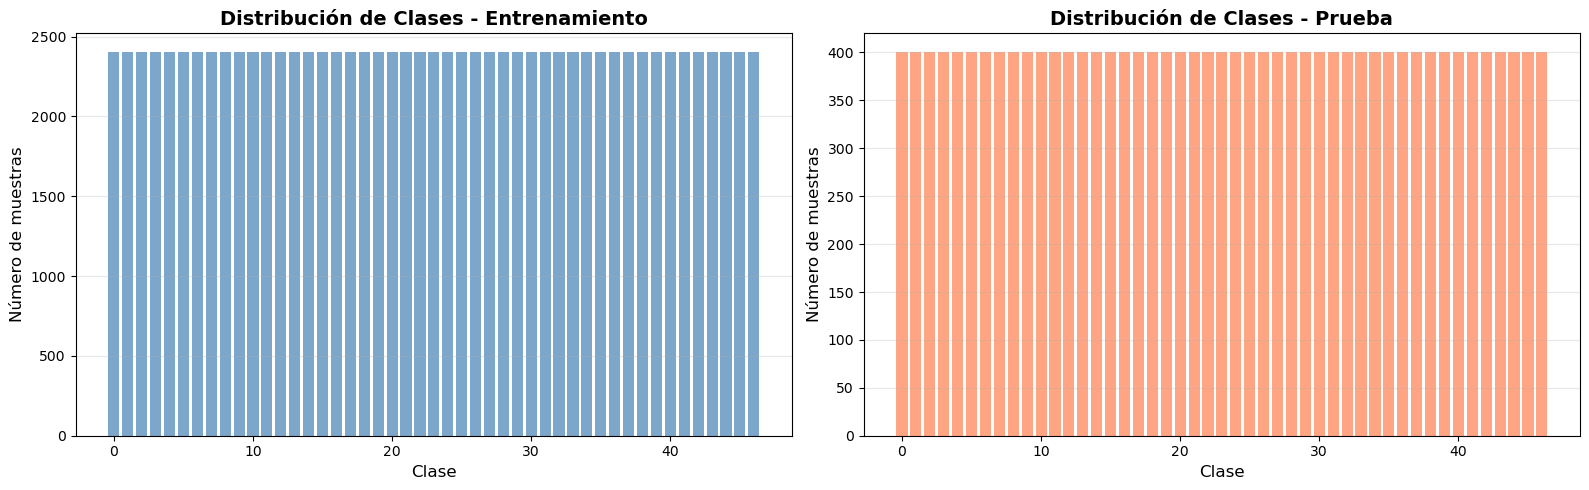

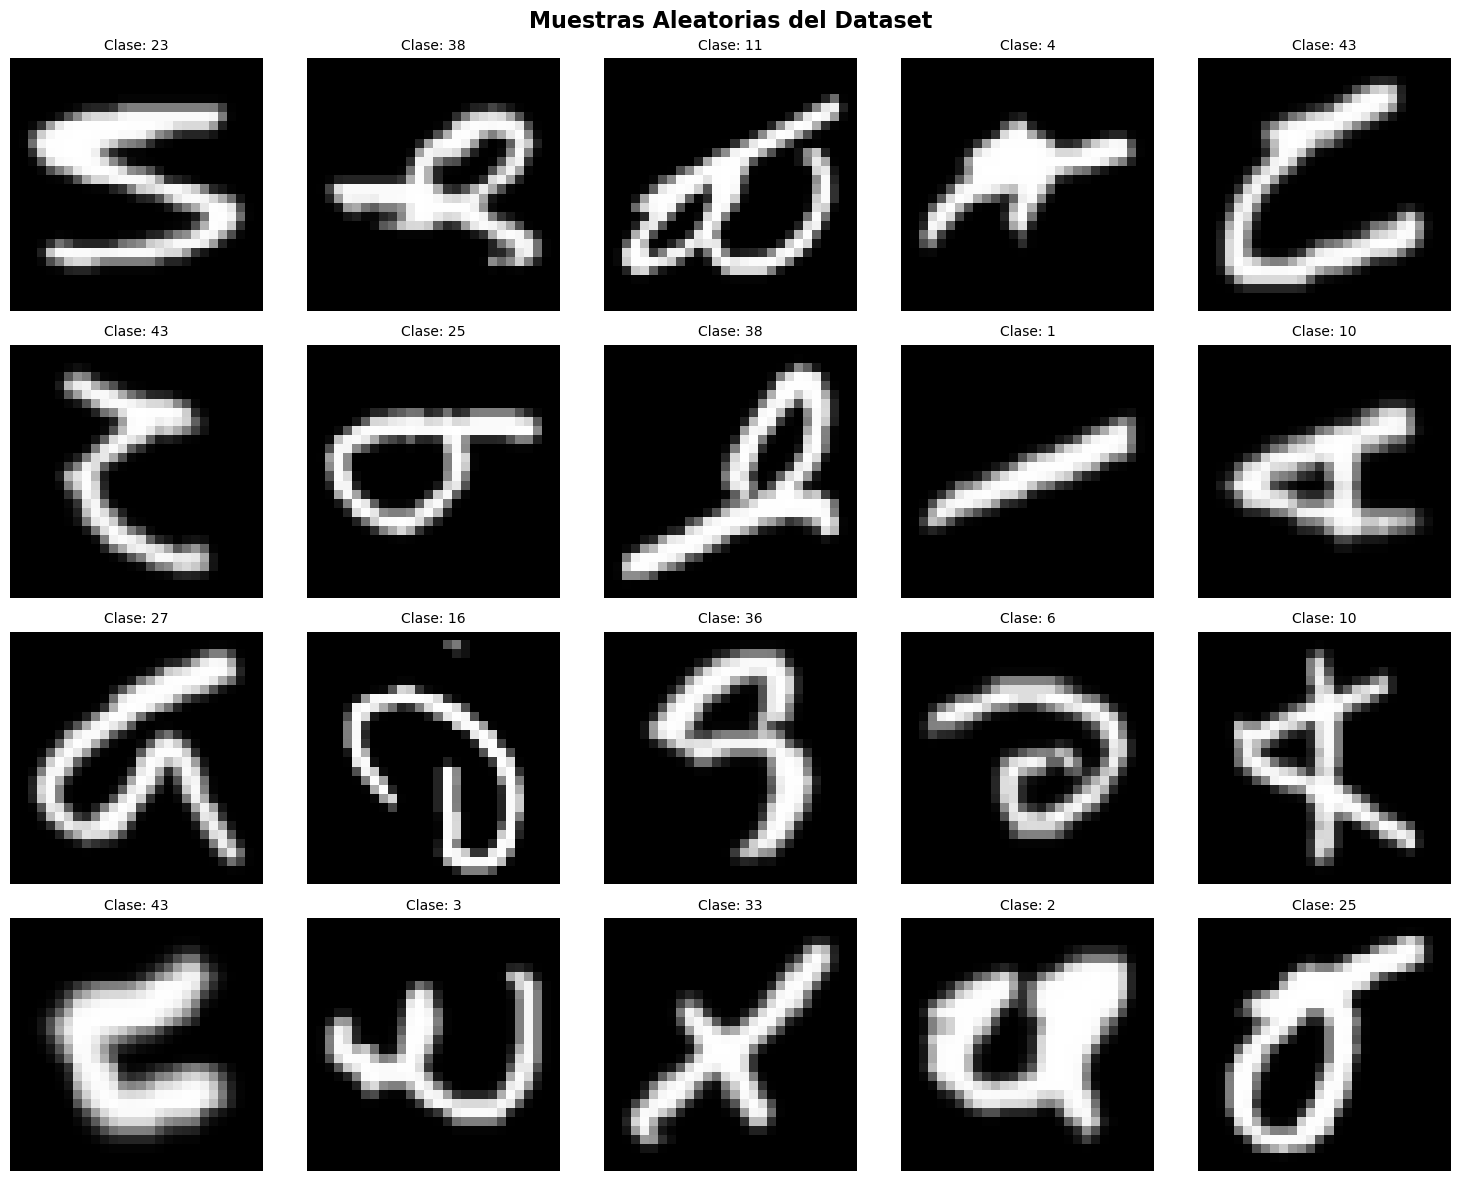

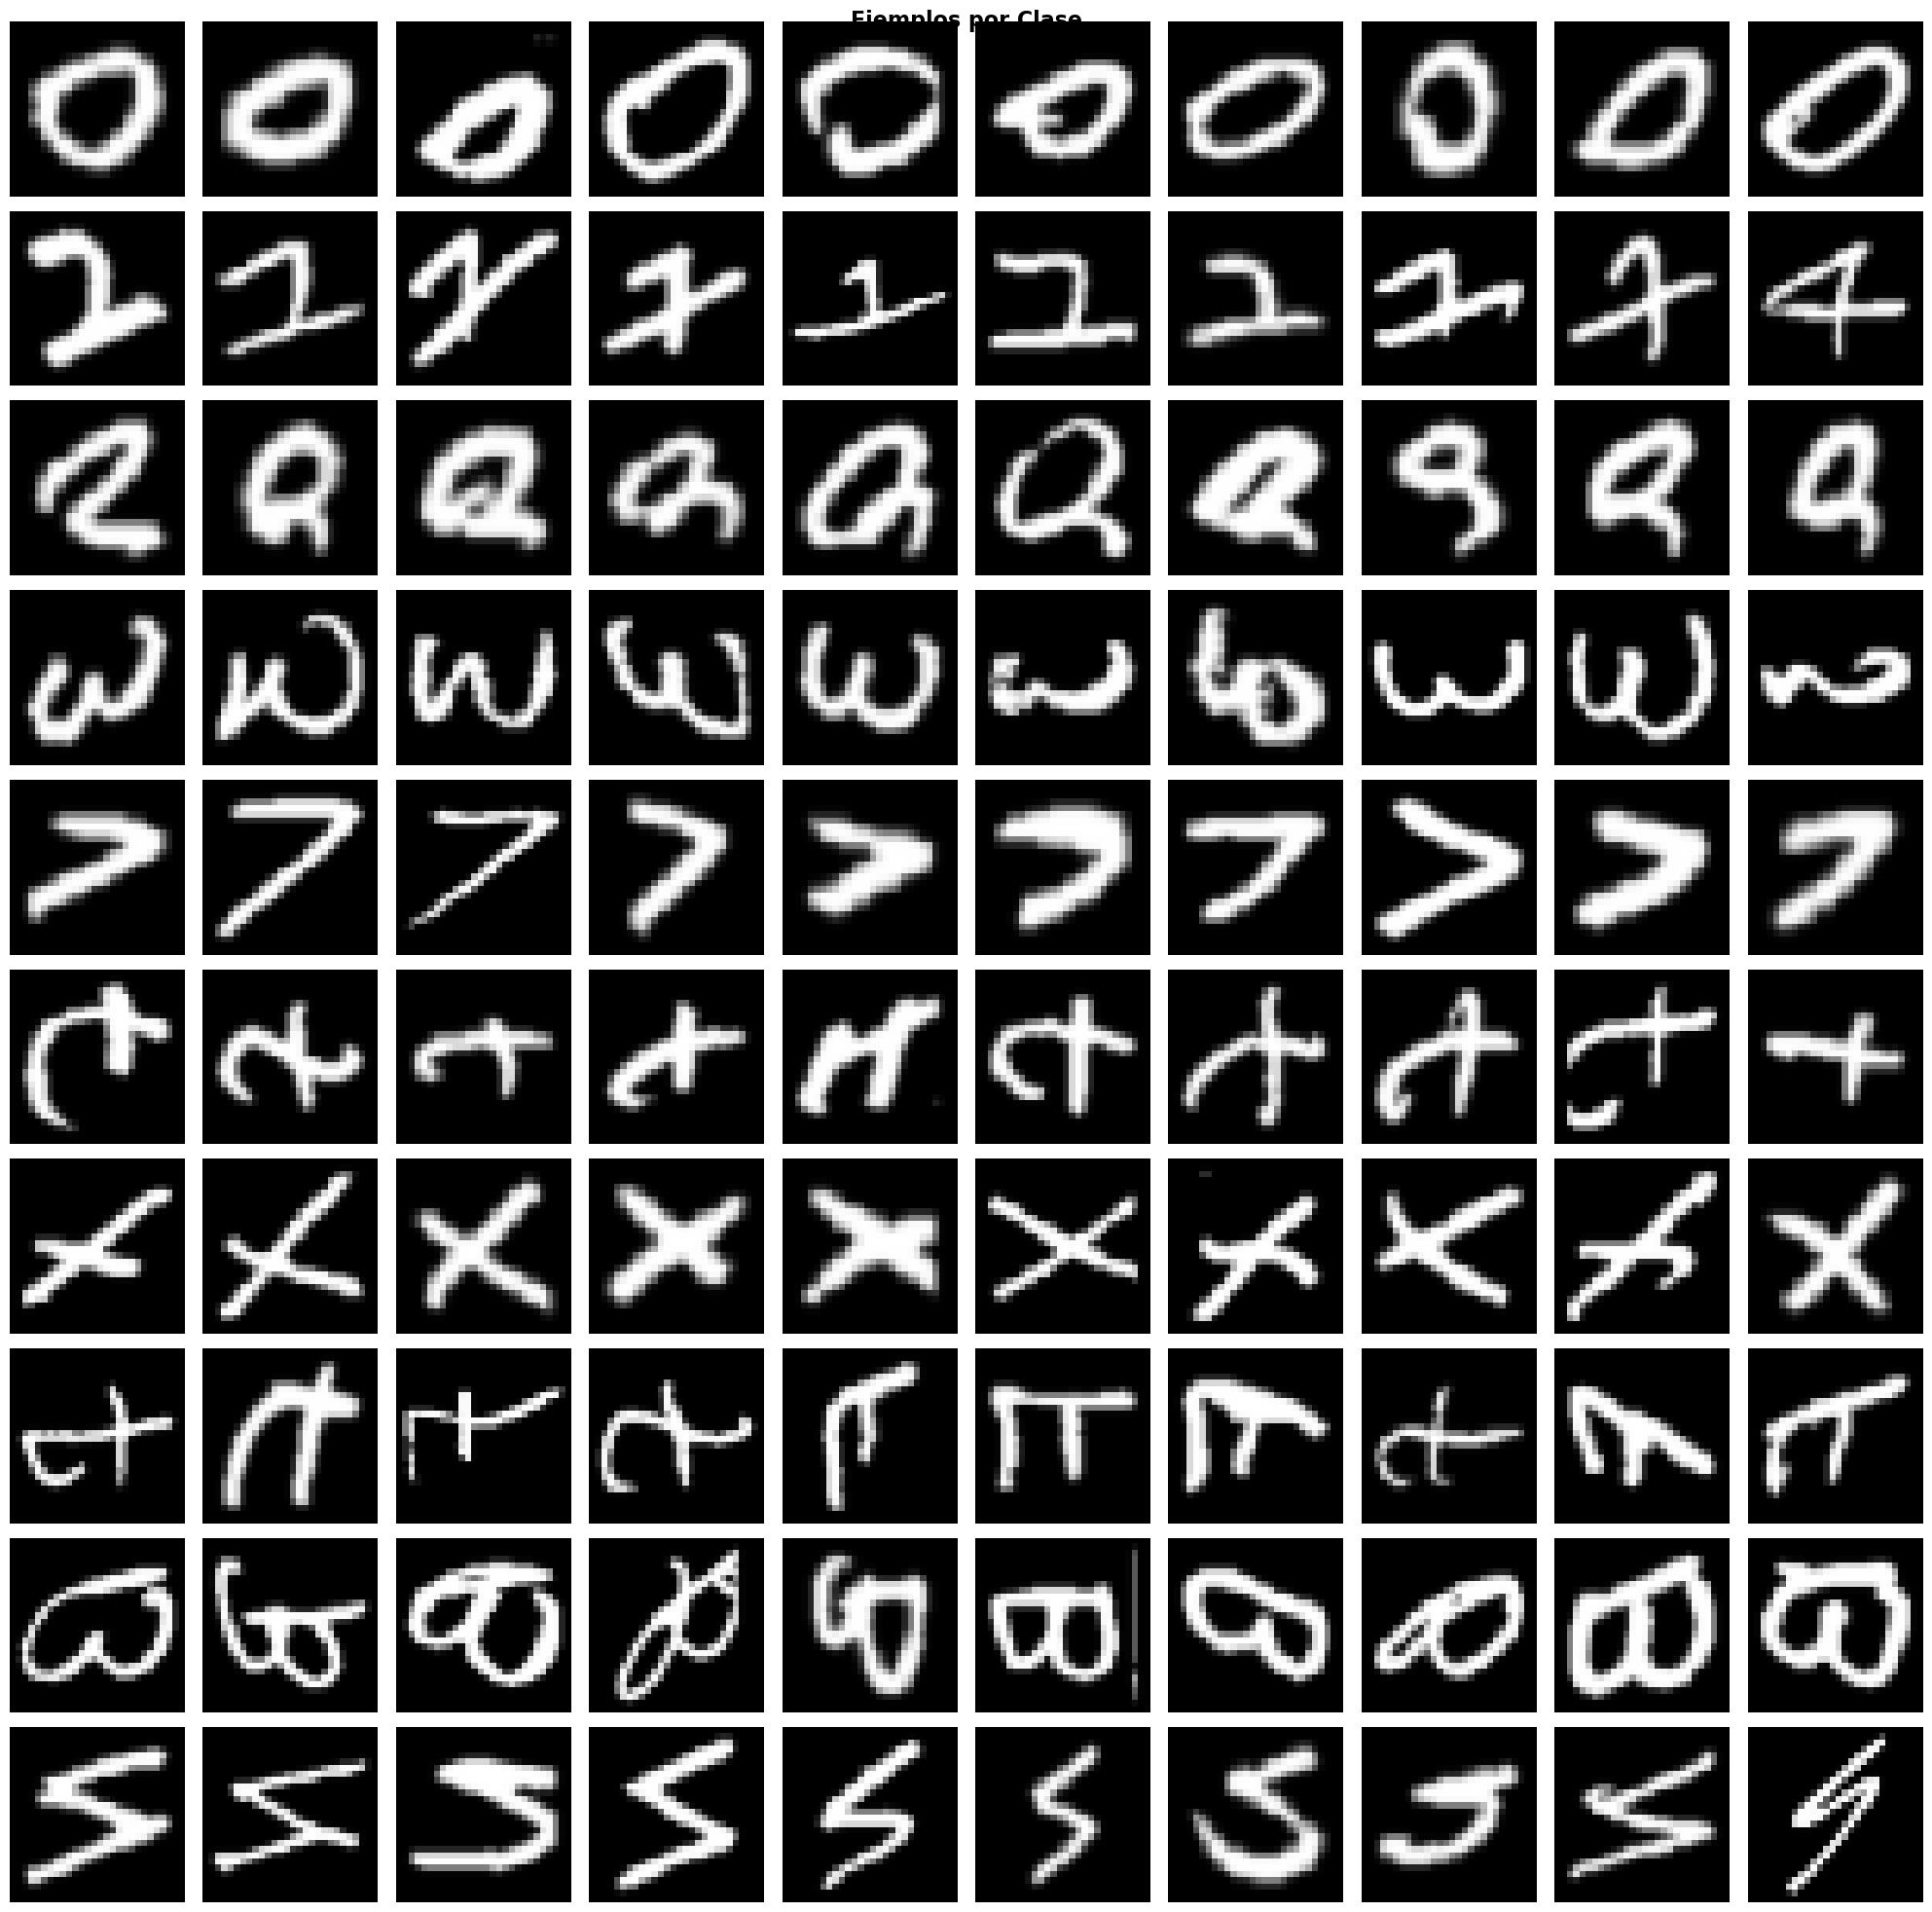


ANÁLISIS DE INTENSIDAD DE PÍXELES

Intensidad promedio global: 44.65
Desviación estándar global: 84.98


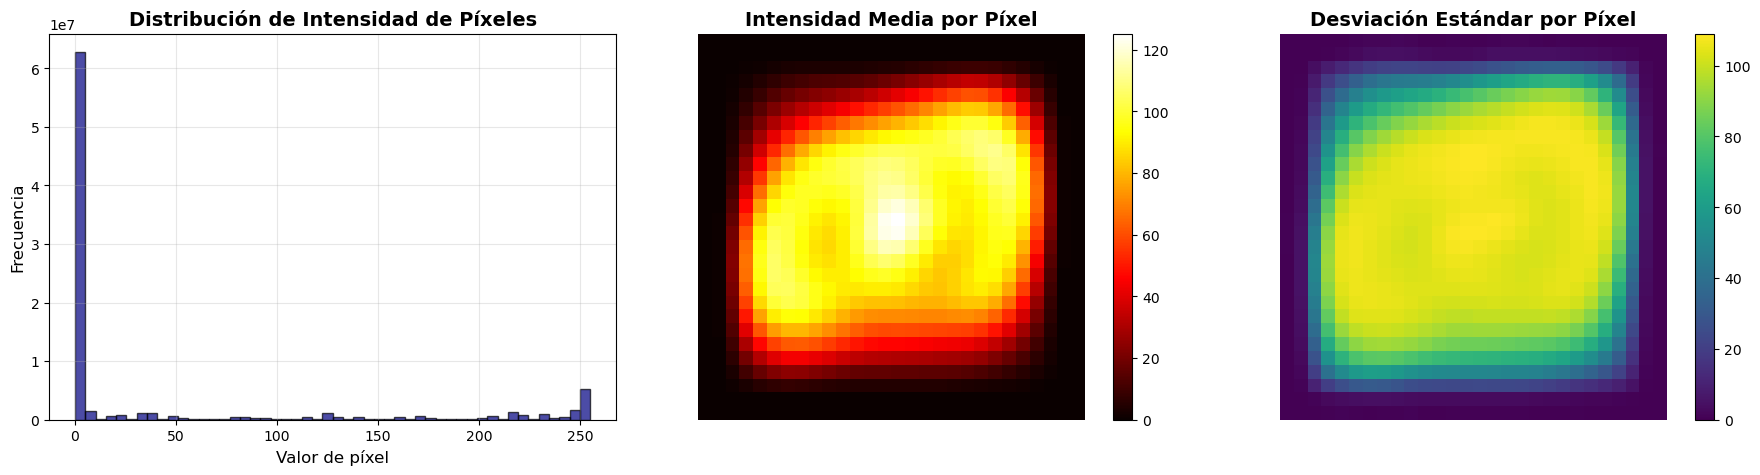


ANÁLISIS DE SIMILITUD ENTRE MUESTRAS


C:\Users\hecto\AppData\Local\Temp\ipykernel_12560\843928794.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


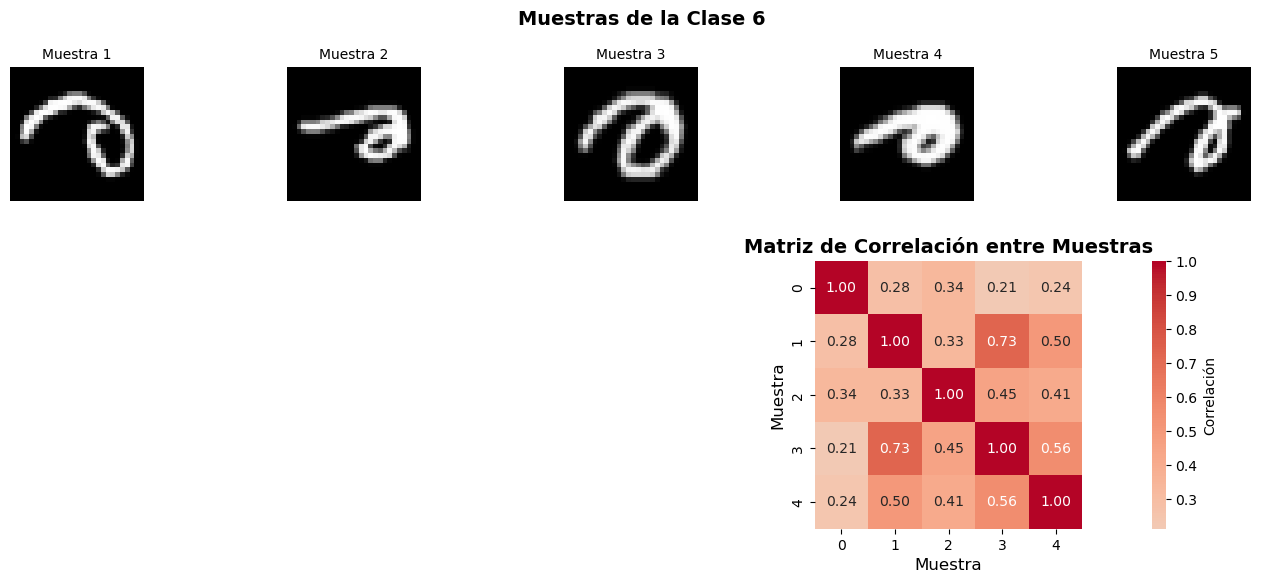


Correlación promedio entre muestras: 0.405


In [74]:
# 2. EXPLORACIÓN EXHAUSTIVA DE DATOS
print("\n2. EXPLORANDO DATOS...")

# Análisis dimensional
explorar_dimensiones(x_train, y_train, x_test, y_test)

# Análisis de clases
counter_train, counter_test = explorar_clases(y_train, y_test)

# Visualizaciones de distribución
visualizar_distribucion_clases(counter_train, counter_test)

# Muestras aleatorias
visualizar_muestras_aleatorias(x_train, y_train, n_muestras=20)

# Muestras por clase
visualizar_muestras_por_clase(x_train, y_train, n_clases=10, n_ejemplos=10)

# Análisis de intensidad de píxeles
analizar_intensidad_pixeles(x_train)

# Análisis de correlación
analizar_correlacion_muestras(x_train, y_train, n_muestras=5)

In [75]:
# 3. Preprocesar
x_train, y_train, x_test, y_test, num_clases = preprocesar_datos(
    x_train, y_train, x_test, y_test
)


PREPROCESAMIENTO DE DATOS

Datos normalizados al rango [0, 1]
Nuevo rango de valores: [0.0, 1.0]

Shape final de entrenamiento: (112800, 28, 28, 1)
Shape final de prueba: (18800, 28, 28, 1)
Número de clases: 47


In [76]:
# 4. Crear modelo
print("\n3. CREANDO MODELO CNN...")
modelo = crear_modelo_cnn(num_clases)
modelo.summary()


3. CREANDO MODELO CNN...


C:\Users\hecto\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 47)             │        12,079 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 399,919 (1.53 MB)

 Trainable params: 399,919 (1.53 MB)

 Non-trainable params: 0 (0.00 B)

In [77]:
# 5. Entrenar
print("\n4. ENTRENANDO MODELO...")
history = entrenar_modelo(
    modelo, x_train, y_train, x_test, y_test,
    epochs=15,
    batch_size=128
)


4. ENTRENANDO MODELO...
Epoch 1/15
794/794 ━━━━━━━━━━━━━━━━━━━━ 32s 38ms/step - accuracy: 0.6812 - loss: 1.0482 - val_accuracy: 0.8435 - val_loss: 0.4493 - learning_rate: 0.0010
Epoch 2/15
794/794 ━━━━━━━━━━━━━━━━━━━━ 30s 37ms/step - accuracy: 0.8174 - loss: 0.5378 - val_accuracy: 0.8624 - val_loss: 0.3856 - learning_rate: 0.0010
Epoch 3/15
794/794 ━━━━━━━━━━━━━━━━━━━━ 41s 37ms/step - accuracy: 0.8379 - loss: 0.4665 - val_accuracy: 0.8715 - val_loss: 0.3603 - learning_rate: 0.0010
Epoch 4/15
794/794 ━━━━━━━━━━━━━━━━━━━━ 30s 38ms/step - accuracy: 0.8495 - loss: 0.4276 - val_accuracy: 0.8785 - val_loss: 0.3415 - learning_rate: 0.0010
Epoch 5/15
794/794 ━━━━━━━━━━━━━━━━━━━━ 35s 44ms/step - accuracy: 0.8579 - loss: 0.4001 - val_accuracy: 0.8804 - val_loss: 0.3252 - learning_rate: 0.0010
Epoch 6/15
794/794 ━━━━━━━━━━━━━━━━━━━━ 39s 41ms/step - accuracy: 0.8623 - loss: 0.3815 - val_accuracy: 0.8816 - val_loss: 0.3224 - learning_rate: 0.0010
Epoch 7/15
794/794 ━━━━━━━━━━━━━━━━━━━━ 34s 42ms/st


5. VISUALIZANDO RESULTADOS...


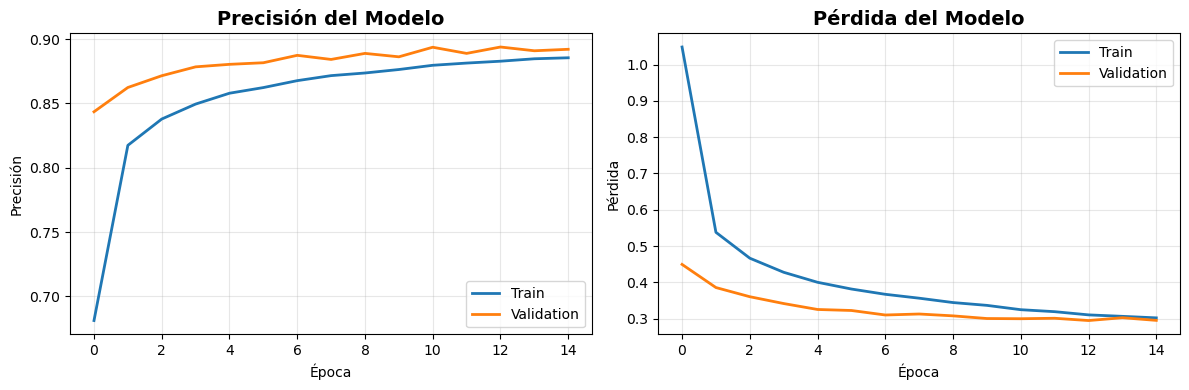

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step


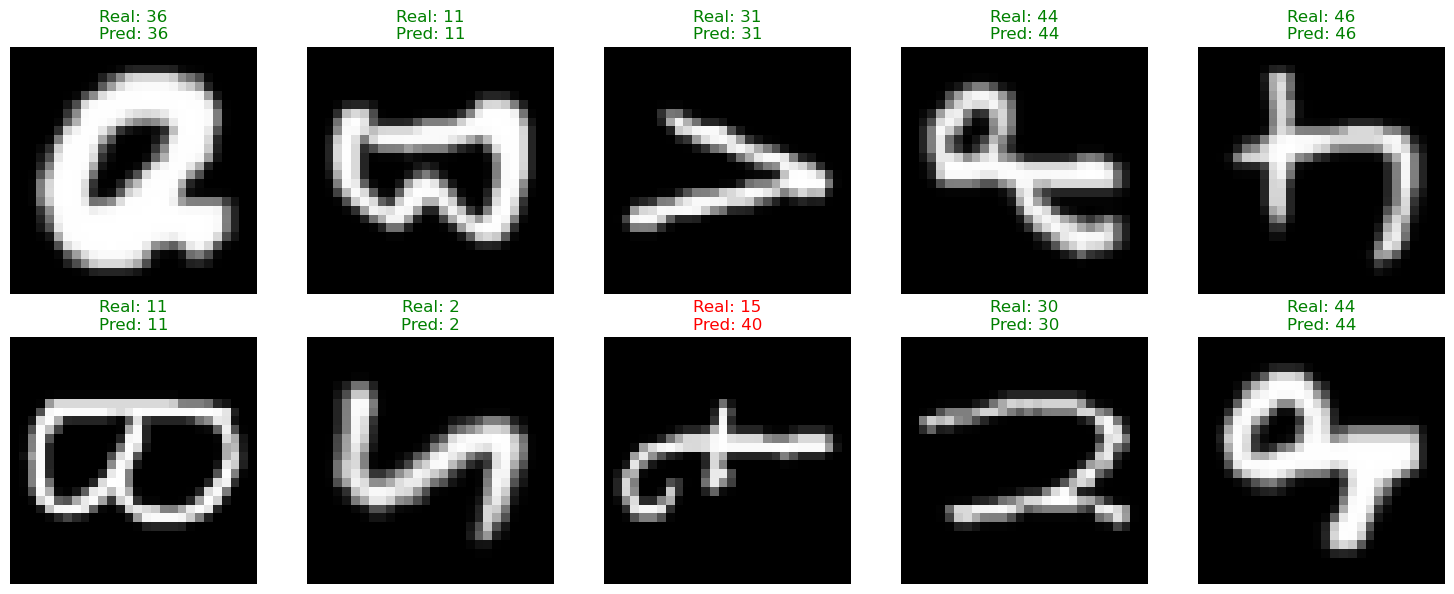

In [78]:
# 6. Visualizar resultados
print("\n5. VISUALIZANDO RESULTADOS...")
visualizar_historial(history)
visualizar_predicciones(modelo, x_test, y_test)

In [79]:
# 7. Guardar modelo
print("\n6. GUARDANDO MODELO...")
modelo.save('modelo_emnist.h5')
print("Modelo guardado como 'modelo_emnist.h5'")


6. GUARDANDO MODELO...
Modelo guardado como 'modelo_emnist.h5'
